In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

train_set = datasets.CIFAR10(root='./datasets', train=True, download=True, transform=transform)
test_set = datasets.CIFAR10(root='./datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, shuffle=True, batch_size=64, pin_memory=True)
test_loader = DataLoader(test_set, shuffle=False, batch_size=64, pin_memory=True)


100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


In [3]:
class PatchPositionEmbedding(nn.Module):
    def __init__(self, embed_dim=512, patch_size=16, image_size=224):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=embed_dim, kernel_size=patch_size, stride=patch_size, bias=False)

        scale = embed_dim ** -0.5
        self.class_embedding = nn.Parameter(scale*torch.randn(embed_dim))
        self.positional_embedding = nn.Parameter(scale * torch.randn(
            (image_size // patch_size) ** 2 + 1, embed_dim
        ))

    def forward(self, x):
        x = self.conv1(x) # shape = [*, width, grid, gird]
        x = x.reshape(x.shape[0], x.shape[1], -1) # shape = [*, width, grid ** 2]
        x = x.permute(0, 2, 1) # shape = [*, grid ** 2, width]

        # expand the cls embedding
        cls_embs = self.class_embedding.to(x.dtype) + torch.zeros(x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device)
        x = torch.cat([cls_embs, x], dim=1) # shape = [*, grid ** 2 + 1, width]
        x = x + self.positional_embedding.to(x.dtype)
        return x

In [4]:
class ViTTransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.norm_1 = nn.LayerNorm(normalized_shape=embed_dim, eps=1e-6)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )
        self.norm_2 = nn.LayerNorm(normalized_shape=embed_dim, eps=1e-6)
        self.ffn = nn.Sequential(
            nn.Linear(in_features=embed_dim, out_features=ff_dim, bias=True),
            nn.GELU(),
            nn.Linear(in_features=ff_dim, out_features=embed_dim, bias=True)
        )
        self.dropout_1 = nn.Dropout(p=dropout)
        self.dropout_2 = nn.Dropout(p=dropout)

    def forward(self, x):
        # layernorm before multi-head attention
        norm_x1 = self.norm_1(x)
        attn_output, _ = self.attn(norm_x1, norm_x1, norm_x1)
        attn_output = self.dropout_1(attn_output)
        x = x + attn_output # residual connection

        # layernorm before feed-forward network
        norm_x2 = self.norm_2(x)
        ffn_output = self.ffn(norm_x2)
        ffn_output = self.dropout_2(ffn_output)
        x = x + ffn_output # resisdual connection
        return x


In [5]:
class VisionTransformerCls(nn.Module):
    def __init__(self, image_size, embed_dim, num_heads, ff_dim, dropout=0.1, num_classes = 10, patch_size=16):
        super().__init__()
        self.embed_layer = PatchPositionEmbedding(
            image_size=image_size, embed_dim=embed_dim, patch_size=patch_size
        )
        self.transformer_layer = ViTTransformerEncoder(
            embed_dim, num_heads, ff_dim, dropout
        )

        self.fc1 = nn.Linear(in_features=embed_dim, out_features=20)
        self.fc2 = nn.Linear(in_features=20, out_features=num_classes)
        self.dropout = nn.Dropout(p=dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        output = self.embed_layer(x)
        output = self.transformer_layer(output)
        output = output[:, 0, :]

        # classification head
        output = self.dropout(output)
        output = self.fc1(output)
        output = self.relu(output)
        output = self.dropout(output)
        output = self.fc2(output)

        return output

In [8]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = VisionTransformerCls(
    image_size=32,
    patch_size=4,
    embed_dim=256,
    num_heads=4,
    ff_dim=128,
    num_classes=10
).to(device)

In [9]:
n_epochs = 50
lr = 1e-5
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.CrossEntropyLoss()

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(n_epochs):
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    model.train()
    for i, batch in enumerate(train_loader):
        x, y = batch
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        y_hat = model(x)
        loss = criterion(y_hat, y)
        train_loss += loss.item()

        _, predicted = torch.max(y_hat, 1)
        correct_train += (predicted == y).sum().item()
        total_train += y.size(0)

        loss.backward()
        optimizer.step()

    train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    print(f"Epoch {epoch + 1} / {n_epochs} loss: {train_loss:0.3f}")

    # evaluate on test set

    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            x, y = batch
            x, y = x.to(device), y.to(device)
            y_hat = model(x)
            loss = criterion(y_hat, y)
            test_loss += loss.item() / len(test_loader)

            _, predicted = torch.max(y_hat, 1)
            correct_test += (predicted == y).sum().item()
            total_test += y.size(0)

    test_accuracy = 100 * correct_test / total_test
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f"test loss: {test_loss:0.3f} accuracy: {test_accuracy:0.2f}%")

Epoch 1 / 50 loss: 2.205
test loss: 2.104 accuracy: 23.77%
Epoch 2 / 50 loss: 2.073
test loss: 1.987 accuracy: 28.76%
Epoch 3 / 50 loss: 1.995
test loss: 1.918 accuracy: 30.54%
Epoch 4 / 50 loss: 1.946
test loss: 1.870 accuracy: 31.65%
Epoch 5 / 50 loss: 1.908
test loss: 1.831 accuracy: 33.28%
Epoch 6 / 50 loss: 1.875
test loss: 1.803 accuracy: 34.32%
Epoch 7 / 50 loss: 1.845
test loss: 1.773 accuracy: 35.46%
Epoch 8 / 50 loss: 1.820
test loss: 1.749 accuracy: 36.72%
Epoch 9 / 50 loss: 1.803
test loss: 1.731 accuracy: 36.97%
Epoch 10 / 50 loss: 1.779
test loss: 1.714 accuracy: 36.92%
Epoch 11 / 50 loss: 1.759
test loss: 1.692 accuracy: 37.81%
Epoch 12 / 50 loss: 1.739
test loss: 1.677 accuracy: 38.36%
Epoch 13 / 50 loss: 1.721
test loss: 1.661 accuracy: 38.87%
Epoch 14 / 50 loss: 1.702
test loss: 1.642 accuracy: 39.70%
Epoch 15 / 50 loss: 1.685
test loss: 1.629 accuracy: 39.85%
Epoch 16 / 50 loss: 1.666
test loss: 1.613 accuracy: 40.43%
Epoch 17 / 50 loss: 1.651
test loss: 1.602 accura

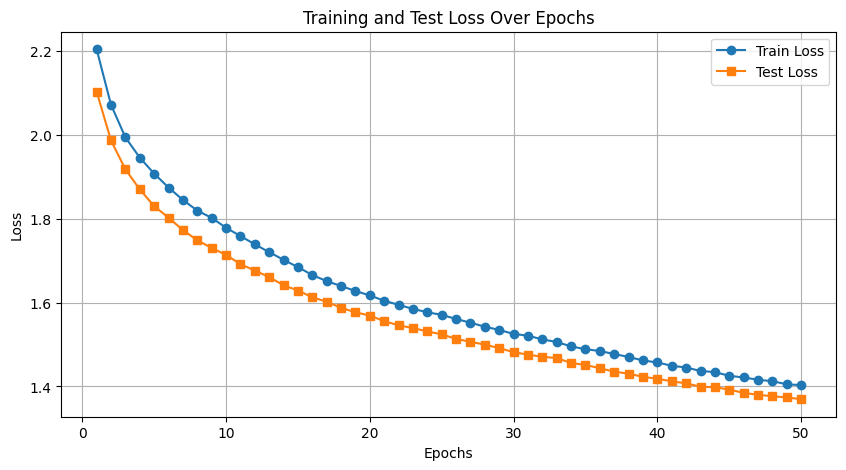

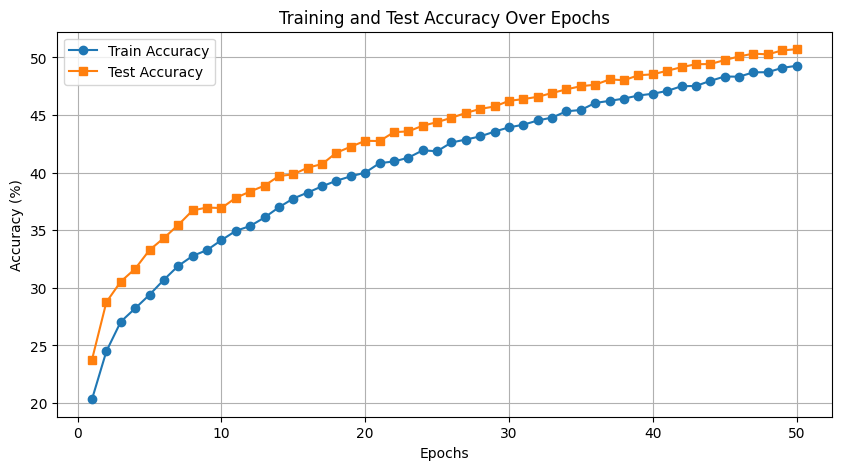

In [10]:
# Plot training and test losses
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, n_epochs + 1), test_losses, label="Test Loss", marker="s")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Test Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and test accuracies
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_accuracies, label="Train Accuracy", marker="o")
plt.plot(range(1, n_epochs + 1), test_accuracies, label="Test Accuracy", marker="s")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training and Test Accuracy Over Epochs")
plt.legend()
plt.grid(True)
plt.show()